# Pound–Drever–Hall (PDH) locking of a diode laser for trapped-ion AMO physics

This notebook develops the optical field and cavity response, constructs the demodulated error signal numerically, connects the discriminator to a feedback loop and noise budget, and finally shows why residual laser noise matters to a trapped-ion carrier transition. The running example is a 729 nm laser addressing the narrow $4S_{1/2}\leftrightarrow 3D_{5/2}$ electric-quadrupole transition in $^{40}\mathrm{Ca}^+$, but the logic applies equally to clock/qubit lasers in $\mathrm{Sr}^+$, $\mathrm{Yb}^+$, $\mathrm{Ba}^+$, and other AMO platforms.

## What you should be able to explain after this notebook

1. Why an ultrastable cavity is a useful *flywheel* even though the ion is the ultimate frequency reference.
2. How phase modulation creates a carrier and sidebands, and why their reflected beat carries the sign of laser detuning.
3. What sets the PDH slope, capture range, offset, and shot-noise-limited frequency sensitivity.
4. How the optical discriminator, electronics, and diode-laser actuators form a feedback loop.
5. How residual detuning noise appears as imperfect Rabi flopping and loss of qubit phase coherence.

The important conceptual chain is

$$\text{laser frequency}\rightarrow\text{cavity phase}\rightarrow\text{RF photocurrent}\rightarrow\text{baseband error voltage}\rightarrow\text{feedback actuator}. $$

## 1. Where PDH sits in a trapped-ion experiment

A typical narrow-linewidth optical path is

```text
ECDL / diode → isolator → phase EOM → cavity → reflection photodiode → mixer → servo
       ↑ slow: temperature/PZT                         │              │
       └──────────── fast: injection current ←────────┴──────────────┘

science branch → AOM(s) → phase-noise-cancelled fiber → trapped ion
                                      ↑
                       slow atomic/comb frequency correction
```

PDH answers **“where is the laser relative to this cavity mode?”**, not “where is the ion transition?” The cavity suppresses fast frequency noise and gives short-term coherence. Slow cavity drift is then removed using ion spectroscopy, an optical frequency comb, or another reference. The AOM provides experiment timing and a programmable frequency offset without asking the cavity lock to jump. Fiber-noise cancellation is needed when the phase accumulated after the pickoff matters at the ion.

AMO viewpoint: the cavity is a high-$Q$ harmonic oscillator with a rapidly varying reflection phase near resonance. PDH is a heterodyne measurement of that phase using sidebands derived coherently from the same laser. Because carrier and sidebands share most path noise, the measurement is robust against ordinary intensity noise to first order.

## 2. Cavity as a frequency-to-phase transducer

For a cavity of length $L$, the free spectral range and intensity full width at half maximum are

$$\nu_{\rm FSR}=\frac{c}{2L},\qquad \Delta\nu_{\rm cav}=\frac{\nu_{\rm FSR}}{\mathcal F},$$

where $\mathcal F$ is the finesse. Near one isolated resonance, input–output theory gives the complex field reflection coefficient

$$r(\Delta)=1-\frac{2\eta}{1-2i\Delta/\Delta\nu_{\rm cav}},\qquad \eta=\frac{\kappa_{\rm in}}{\kappa}. $$

$\Delta=\nu_L-\nu_c$ is in Hz, $\kappa/2\pi=\Delta\nu_{\rm cav}$, and $\eta$ is the fraction of total field-energy decay through the input coupler. At critical coupling ($\eta=1/2$) the promptly reflected and cavity leakage fields cancel on resonance. Imperfect spatial mode matching adds a non-resonant reflected field and reduces the usable discriminator slope.

The cavity does **not** magically define an absolute optical frequency. Its resonance follows $\nu_c\simeq mc/(2nL)$, so spacer thermal noise, vibration, residual gas index, mirror coating noise, and slow creep all become frequency noise. Fractionally, $\delta\nu_c/\nu_c\simeq-\delta L/L$ in vacuum.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c, hbar, e, physical_constants, pi
from scipy.special import jv

# Publication-style defaults. Arial is installed on this system; the remaining
# entries are fallbacks for portability on machines without the Microsoft fonts.
COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "sky": "#56B4E9",
    "gray": "#5B5B5B",
    "black": "#202020",
}

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 16,
    "mathtext.fontset": "stixsans",
    "mathtext.default": "regular",
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 16,
    "axes.linewidth": 1.2,
    "axes.edgecolor": COLORS["black"],
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#C9C9C9",
    "grid.alpha": 0.35,
    "grid.linewidth": 0.8,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "xtick.color": COLORS["black"],
    "ytick.color": COLORS["black"],
    "legend.fontsize": 16,
    "legend.frameon": False,
    "lines.linewidth": 2.4,
    "lines.markersize": 7,
    "figure.figsize": (8.5, 5.5),
    "figure.dpi": 140,
    "figure.facecolor": "white",
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
})

def polish_axes(axes, panel_labels=True):
    """Apply consistent journal-style axis details to one or more axes."""
    axes = np.atleast_1d(axes).ravel()
    for index, axis in enumerate(axes):
        axis.spines["top"].set_visible(False)
        axis.spines["right"].set_visible(False)
        axis.tick_params(which="major", direction="out", length=6, width=1.2,
                         bottom=True, left=True, top=False, right=False)
        axis.tick_params(which="minor", direction="out", length=3.5, width=1.0,
                         bottom=True, left=True, top=False, right=False)
        axis.minorticks_on()
        if panel_labels and len(axes) > 1:
            axis.text(-0.14, 1.06, f"({chr(97 + index)})", transform=axis.transAxes,
                      fontsize=16, fontweight="bold", va="top", ha="left")
    return axes

def cavity_r(detuning_hz, linewidth_hz, eta=0.50):
    """Near-resonant complex field reflection coefficient."""
    x = np.asarray(detuning_hz) / linewidth_hz
    return 1 - 2 * eta / (1 - 2j * x)

def pdh_rf_phasor(detuning_hz, linewidth_hz, f_mod_hz, beta, eta=0.50, nmax=8):
    """Complex photocurrent phasor at +f_mod, including several PM sidebands."""
    detuning_hz = np.asarray(detuning_hz)
    ns = np.arange(-nmax, nmax + 1)
    # A_n is the reflected optical field at omega + n*Omega.
    A = np.array([
        jv(n, beta) * cavity_r(detuning_hz + n*f_mod_hz, linewidth_hz, eta)
        for n in ns
    ])
    # I_(+Omega) = sum_n A_(n+1) A_n^*.
    return np.sum(A[1:] * np.conj(A[:-1]), axis=0)

def optimal_demod_phase(linewidth_hz, f_mod_hz, beta, eta=0.50):
    """Mixer phase that makes the on-resonance error slope positive and maximal."""
    eps = linewidth_hz * 1e-5
    dC = (
        pdh_rf_phasor(eps, linewidth_hz, f_mod_hz, beta, eta)
        - pdh_rf_phasor(-eps, linewidth_hz, f_mod_hz, beta, eta)
    ) / (2*eps)
    return np.angle(dC)

def pdh_error(detuning_hz, linewidth_hz, f_mod_hz, beta, eta=0.50, phase=None):
    C = pdh_rf_phasor(detuning_hz, linewidth_hz, f_mod_hz, beta, eta)
    if phase is None:
        phase = optimal_demod_phase(linewidth_hz, f_mod_hz, beta, eta)
    return np.real(C * np.exp(-1j * phase))

In [5]:
# Illustrative ultrastable reference cavity
wavelength = 729e-9
L = 0.10                 # m
finesse = 3.0e5
eta_coupling = 0.50      # critical coupling
fsr = c / (2*L)
linewidth = fsr / finesse
q_cavity = (c/wavelength) / linewidth
photon_lifetime = 1 / (2*pi*linewidth)  # energy ringdown time

print(f"Optical frequency       = {c/wavelength/1e12:.3f} THz")
print(f"Free spectral range     = {fsr/1e9:.3f} GHz")
print(f"Cavity FWHM             = {linewidth/1e3:.3f} kHz")
print(f"Optical Q               = {q_cavity:.2e}")
print(f"Energy ringdown time    = {photon_lifetime*1e6:.1f} microseconds")
print(f"1 Hz at 729 nm is a fractional shift of {1/(c/wavelength):.2e}")

Optical frequency       = 411.238 THz
Free spectral range     = 1.499 GHz
Cavity FWHM             = 4.997 kHz
Optical Q               = 8.23e+10
Energy ringdown time    = 31.9 microseconds
1 Hz at 729 nm is a fractional shift of 2.43e-15


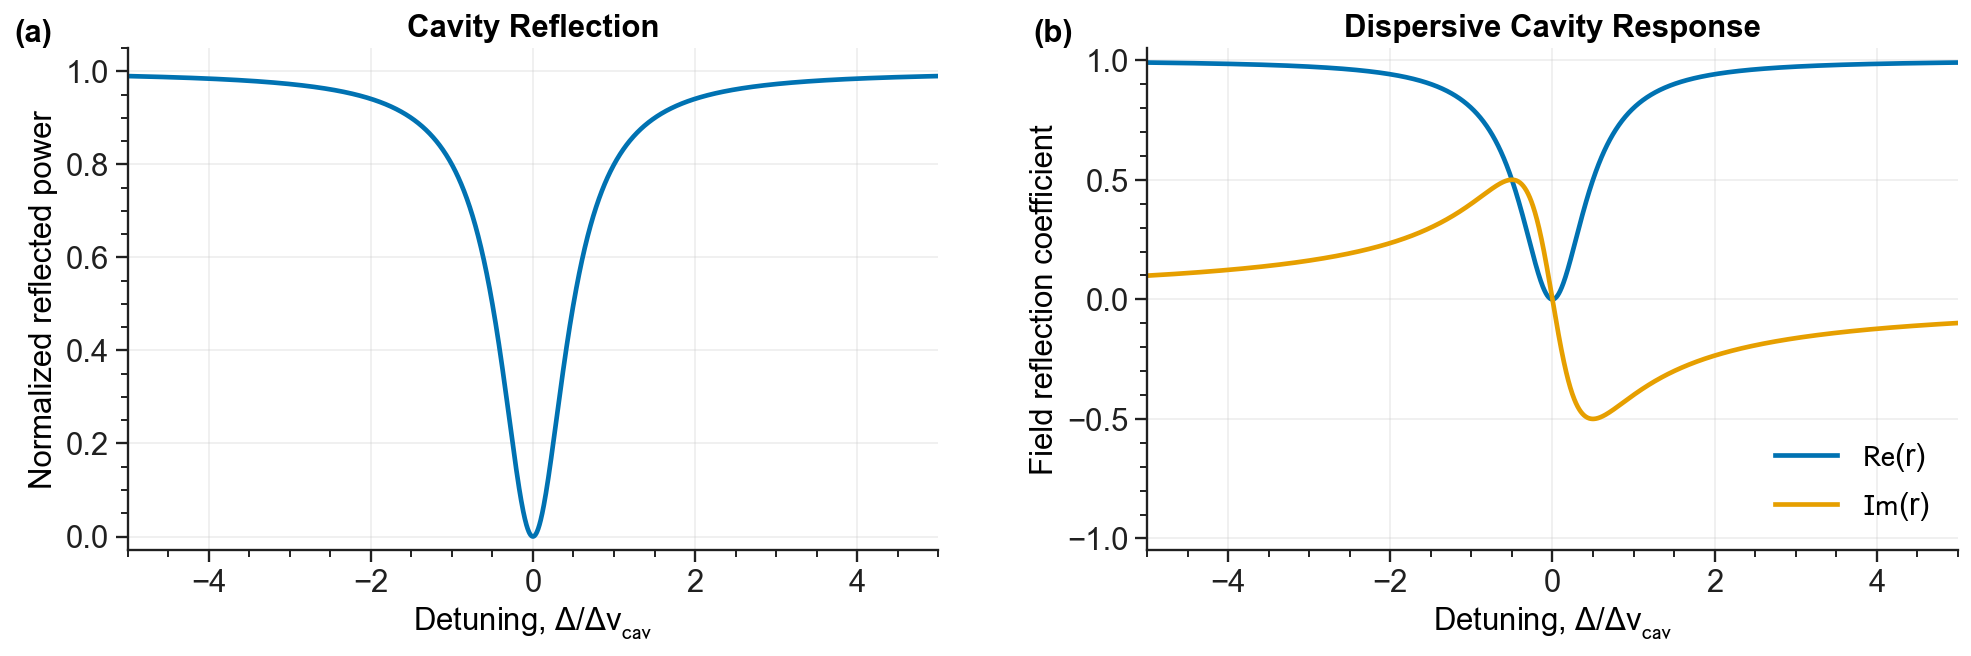

In [9]:
d = np.linspace(-5, 5, 2001) * linewidth
r = cavity_r(d, linewidth, eta_coupling)

fig, ax = plt.subplots(1, 2, figsize=(14.5, 5.2))
ax[0].plot(d/linewidth, np.abs(r)**2, color=COLORS["blue"])
ax[0].set(
    xlabel=r"Detuning, $\Delta/\Delta\nu_{\mathrm{cav}}$",
    ylabel="Normalized reflected power",
    title="Cavity Reflection",
    xlim=(-5, 5), ylim=(-0.03, 1.05),
)

ax[1].plot(d/linewidth, np.real(r), color=COLORS["blue"], label=r"$\mathrm{Re}(r)$")
ax[1].plot(d/linewidth, np.imag(r), color=COLORS["orange"], label=r"$\mathrm{Im}(r)$")
ax[1].set(
    xlabel=r"Detuning, $\Delta/\Delta\nu_{\mathrm{cav}}$",
    ylabel="Field reflection coefficient",
    title="Dispersive Cavity Response",
    xlim=(-5, 5), ylim=(-1.05, 1.05),
)
ax[1].legend(loc="lower right")
polish_axes(ax)
fig.tight_layout(pad=1.6, w_pad=2.4)
plt.show()

## 3. Phase modulation and the PDH signal: step-by-step derivation

We use the **analytic optical field** convention: the measurable electric field is the real part of $E(t)$, and the photodiode responds to the cycle-averaged magnitude $|E(t)|^2$. Define

$$
\Delta=\nu_L-\nu_c,\qquad \Omega=2\pi f_m,
$$

where $\Delta$ is written in Hz in the cavity response $r(\Delta)$, while $\Omega$ is the angular modulation frequency. The derivation assumes:

1. phase modulation is applied before the cavity;
2. the carrier is close to one cavity mode;
3. the modulation sidebands do not overlap another longitudinal or transverse mode;
4. the photodiode is fast enough to detect the beat at $f_m$;
5. optical frequencies themselves are far above the detector bandwidth and are averaged away.

The goal is to calculate the photocurrent component at $f_m$ and show why its phase-sensitive amplitude changes sign at cavity resonance.

### Step 1 — The EOM creates a carrier and phase-coherent sidebands

An ideal phase EOM adds a sinusoidal phase $\beta\sin\Omega t$ to the laser:

$$
E_{\rm in}(t)=E_0e^{i\omega t+i\beta\sin\Omega t}.
$$

Use the Jacobi–Anger expansion

$$
e^{i\beta\sin\Omega t}=\sum_{n=-\infty}^{\infty}J_n(\beta)e^{in\Omega t}
$$

to obtain

$$
E_{\rm in}(t)=E_0\sum_{n=-\infty}^{\infty}J_n(\beta)
e^{i(\omega+n\Omega)t}.
$$

For moderate $\beta$, retain the carrier and first-order sidebands. Since $J_{-1}(\beta)=-J_1(\beta)$,

$$
E_{\rm in}(t)\approx E_0e^{i\omega t}
\left[J_0+J_1e^{i\Omega t}-J_1e^{-i\Omega t}\right].
$$

Thus the three important components are

| component | optical frequency | field amplitude | power fraction |
|---|---:|---:|---:|
| lower sideband | $\omega-\Omega$ | $-J_1E_0$ | $J_1^2$ |
| carrier | $\omega$ | $J_0E_0$ | $J_0^2$ |
| upper sideband | $\omega+\Omega$ | $+J_1E_0$ | $J_1^2$ |

The minus sign of the lower sideband is crucial: it is the relative phase relation of **phase modulation**. Also, $\sum_nJ_n^2(\beta)=1$, so an ideal EOM redistributes optical power rather than creating or destroying it.

### Step 2 — Each frequency component sees a different cavity reflection coefficient

Let

$$
r_0=r(\Delta),\qquad r_+=r(\Delta+f_m),\qquad r_-=r(\Delta-f_m).
$$

Reflection multiplies each component by the complex cavity response at its own optical frequency:

$$
E_{\rm refl}(t)\approx E_0e^{i\omega t}
\left[J_0r_0+J_1r_+e^{i\Omega t}-J_1r_-e^{-i\Omega t}\right].
$$

It is useful to define slowly varying complex amplitudes

$$
b_0=J_0r_0,\qquad b_+=J_1r_+,\qquad b_-=-J_1r_-.
$$

Near resonance, $r_0$ changes rapidly in both amplitude and phase. If $f_m\gg\Delta\nu_{\rm cav}$, the sidebands remain far from resonance and act as nearly unchanged phase references. This is the optical analogue of heterodyne detection: the sidebands are local oscillators derived coherently from the laser itself.

### Step 3 — Square-law photodetection produces an RF beat at $f_m$

The photodiode averages over the optical carrier but resolves the modulation frequency:

$$
i(t)\propto |E_{\rm refl}(t)|^2.
$$

After removing the common $e^{i\omega t}$, expand the product:

$$
\frac{i(t)}{\mathcal R P_0}
=\left|b_-e^{-i\Omega t}+b_0+b_+e^{i\Omega t}\right|^2,
$$

where $P_0$ is incident optical power and $\mathcal R$ is detector responsivity. Terms with equal optical frequencies give DC. Terms separated by $\Omega$ give the photocurrent at $f_m$:

$$
i_{f_m}(t)=2\mathcal R P_0\operatorname{Re}\!\left[C_1e^{i\Omega t}\right],
$$

with

$$
\begin{aligned}
C_1
&=b_+b_0^*+b_0b_-^*\\
&=J_0J_1\left[r_+r_0^*-r_0r_-^*\right]\\
&=J_0J_1\left[r(\Delta+f_m)r^*(\Delta)
-r(\Delta)r^*(\Delta-f_m)\right].
\end{aligned}
$$

This is the central PDH result before demodulation. The first term is the upper-sideband/carrier beat; the second is the carrier/lower-sideband beat. Their subtraction comes directly from $J_{-1}=-J_1$.

For arbitrary modulation depth, adjacent sidebands also beat at $f_m$:

$$
C_1=\sum_{n=-\infty}^{\infty}A_{n+1}A_n^*,\qquad
A_n=J_n(\beta)r(\Delta+n f_m).
$$

The numerical function `pdh_rf_phasor` evaluates this full sum rather than stopping at first order.

### Step 4 — The mixer selects one RF quadrature

Write the RF photocurrent as

$$
i_{f_m}(t)=2\mathcal R P_0|C_1|\cos\!\left(\Omega t+\arg C_1\right).
$$

The electronic local oscillator is

$$
V_{\rm LO}(t)=V_{\rm LO,0}\cos(\Omega t+\phi).
$$

Multiplying the two signals gives a sum-frequency term at $2\Omega$ and a difference-frequency term. The low-pass filter rejects the $2\Omega$ term, leaving

$$
\boxed{\epsilon(\Delta,\phi)=K\operatorname{Re}\!\left[C_1(\Delta)e^{-i\phi}\right]},
$$

where $K$ contains detector responsivity, RF gain, mixer conversion, LO amplitude, and transimpedance. Changing cable length or mixer phase rotates $phi$ and therefore chooses which quadrature of $C_1$ is measured. The optimized phase maximizes $d\epsilon/d\Delta$ at resonance; a phase shifted by $90^\circ$ ideally has no discriminator slope.

### Step 5 — Far-off-resonant sidebands reveal the dispersive cavity phase

Take the usual PDH limit

$$
\Delta\nu_{\rm cav}\ll f_m\ll\nu_{\rm FSR}.
$$

The sidebands are then reflected nearly unchanged, $r_+\approx r_-\approx1$. Therefore

$$
\begin{aligned}
C_1
&\approx J_0J_1(r_0^*-r_0)\\
&=-2iJ_0J_1\operatorname{Im}r(\Delta).
\end{aligned}
$$

The amplitude response that appears in ordinary cavity reflection has become a measurement of the **imaginary, dispersive field response**. Insert the near-resonant cavity model from Section 2,

$$
r(\Delta)=1-\frac{2\eta}{1-2i\Delta/\Delta\nu_{\rm cav}},
$$

and define $x=\Delta/\Delta\nu_{\rm cav}$. Its imaginary part is

$$
\operatorname{Im}r(\Delta)=-\frac{4\eta x}{1+4x^2}.
$$

Hence

$$
C_1\approx 8i\eta J_0(\beta)J_1(\beta)\frac{x}{1+4x^2}.
$$

With the present convention, choosing $\phi=+\pi/2$ rotates this imaginary phasor onto the real mixer output:

$$
\boxed{
\epsilon_{\rm norm}(\Delta)
=8\eta J_0J_1\frac{\Delta/\Delta\nu_{\rm cav}}
{1+4(\Delta/\Delta\nu_{\rm cav})^2}
}.
$$

The overall sign is not fundamental—it reverses if the mixer port, electronic gain, detuning definition, or servo actuator sign is reversed. What matters is the odd zero crossing and the chosen negative-feedback sign.

### Step 6 — Linearize at resonance to obtain the frequency discriminator

For $|\Delta|\ll\Delta\nu_{\rm cav}$,

$$
\epsilon_{\rm norm}(\Delta)
\approx \frac{8\eta J_0J_1}{\Delta\nu_{\rm cav}}\,\Delta.
$$

Therefore the normalized on-resonance slope is

$$
\boxed{
\left.\frac{d\epsilon_{\rm norm}}{d\nu}\right|_{\Delta=0}
=\frac{8\eta J_0(\beta)J_1(\beta)}{\Delta\nu_{\rm cav}}
}.
$$

This formula explains the main design trends:

- a narrower cavity gives a steeper discriminator;
- optical coupling enters through $\eta$ and experimental mode matching;
- modulation depth enters through $J_0J_1$;
- detector power and electronic gain multiply this normalized slope to give V/Hz;
- the extrema occur near $|\Delta|=\Delta\nu_{\rm cav}/2$, so the useful linear range is only a fraction of the linewidth.

Finally, the physical picture is simple: **the carrier probes the cavity phase, the sidebands provide phase references, the photodiode converts their optical interference into an RF phasor, and the mixer converts the correct RF quadrature into a signed frequency error.**

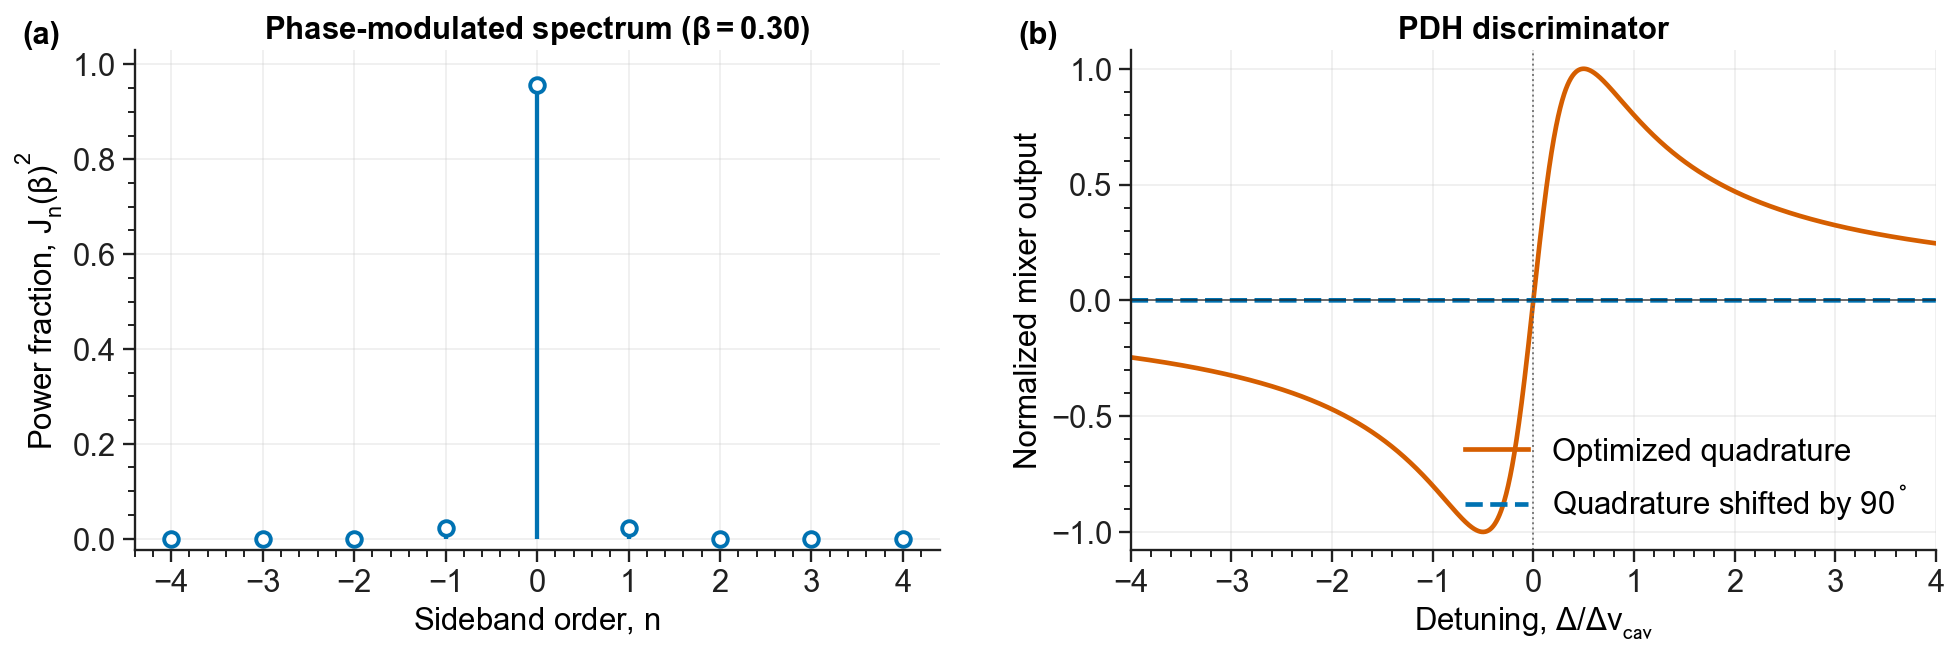

Carrier power fraction: 0.9558
Power in each first sideband: 0.0220
Optimal demodulation phase in this convention: 90.0 deg


In [4]:
f_mod = 20e6            # above 5 kHz linewidth and below 1.5 GHz FSR
beta = 0.30
det = np.linspace(-4, 4, 2401) * linewidth
phi_opt = optimal_demod_phase(linewidth, f_mod, beta, eta_coupling)
err = pdh_error(det, linewidth, f_mod, beta, eta_coupling, phi_opt)

orders = np.arange(-4, 5)
powers = jv(orders, beta)**2

fig, ax = plt.subplots(1, 2, figsize=(14.5, 5.2))
markerline, stemlines, baseline = ax[0].stem(orders, powers, basefmt=" ")
plt.setp(stemlines, color=COLORS["blue"], linewidth=2.2)
plt.setp(markerline, marker="o", markersize=7.5, markerfacecolor="white",
         markeredgecolor=COLORS["blue"], markeredgewidth=2.0)
ax[0].set(
    xlabel="Sideband order, $n$",
    ylabel=r"Power fraction, $J_n(\beta)^2$",
    title=fr"Phase-modulated spectrum ($\beta={beta:.2f}$)",
    xticks=orders, ylim=(-0.025, 1.03),
)

ax[1].plot(det/linewidth, err/np.max(np.abs(err)), color=COLORS["red"],
           label="Optimized quadrature")
ax[1].plot(
    det/linewidth,
    pdh_error(det, linewidth, f_mod, beta, eta_coupling, phi_opt+np.pi/2)/np.max(np.abs(err)),
    color=COLORS["blue"], ls="--", label=r"Quadrature shifted by $90^\circ$",
)
ax[1].axhline(0, color=COLORS["black"], lw=1.0, alpha=0.65)
ax[1].axvline(0, color=COLORS["gray"], lw=1.0, ls=":", alpha=0.8)
ax[1].set(
    xlabel=r"Detuning, $\Delta/\Delta\nu_{\mathrm{cav}}$",
    ylabel="Normalized mixer output",
    title="PDH discriminator",
    xlim=(-4, 4), ylim=(-1.08, 1.08),
)
ax[1].legend(loc="lower right")
polish_axes(ax)
fig.tight_layout(pad=1.6, w_pad=2.4)
plt.show()

print(f"Carrier power fraction: {jv(0,beta)**2:.4f}")
print(f"Power in each first sideband: {jv(1,beta)**2:.4f}")
print(f"Optimal demodulation phase in this convention: {np.degrees(phi_opt):.1f} deg")

### What the error curve is—and is not

Near resonance, linearize the measured voltage as

$$V_{\rm err}\simeq D\,(\nu_L-\nu_c)+V_{\rm off},\qquad D=\left.\frac{dV_{\rm err}}{d\nu}\right|_0. $$

The discriminator $D$ in V/Hz must be **measured** by scanning through a known frequency interval or applying a calibrated frequency modulation. The useful linear range is only of order the cavity linewidth. PDH is therefore an excellent *holding* lock but acquisition normally needs a slow scan/search or transmission threshold.

The signal is zero at the desired resonance only under ideal pure PM. Residual amplitude modulation (RAM), etalons, detector offsets, electronic LO leakage, and mode-mismatch produce $V_{\rm off}$, shifting the lock by

$$\delta\nu_{\rm lock}=-\frac{V_{\rm off}}{D}. $$

That compact equation is why RAM is dangerous for high-accuracy ion spectroscopy: more loop gain cannot remove a sensor offset. Temperature-stabilizing the EOM, aligning its polarization to a principal axis, removing parasitic etalons, and servoing RAM are common remedies.

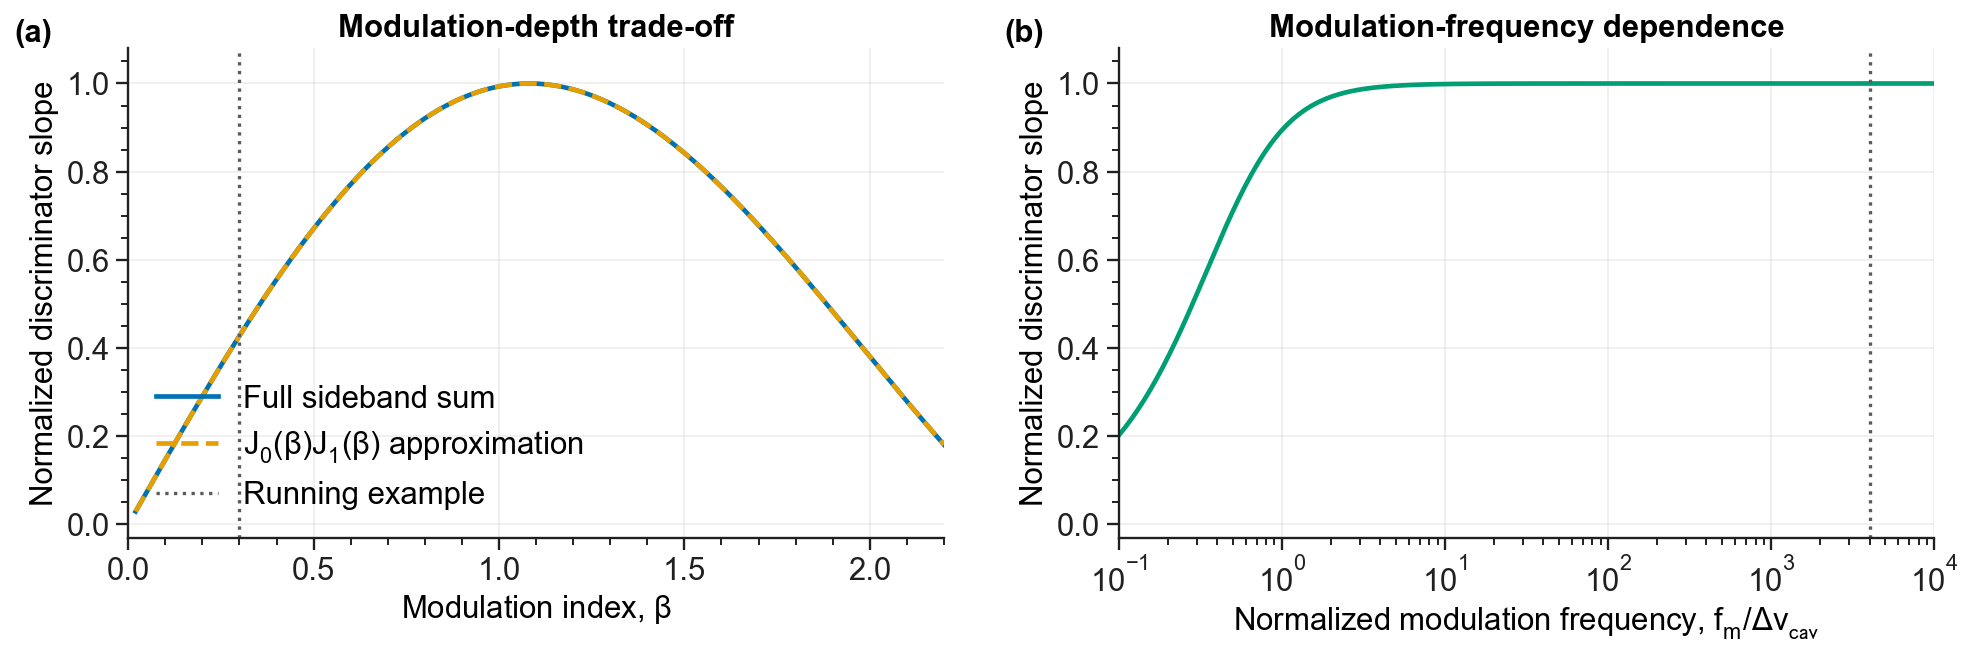

Maximum slope in this model occurs near beta = 1.08.
Many labs use beta ~ 0.2–0.7 to retain carrier power and limit higher sidebands.


In [5]:
# Numerical design study: slope versus modulation depth and modulation frequency.
def zero_slope(beta_value, fmod_value):
    step = linewidth * 1e-4
    phase = optimal_demod_phase(linewidth, fmod_value, beta_value, eta_coupling)
    return (
        pdh_error(step, linewidth, fmod_value, beta_value, eta_coupling, phase)
        - pdh_error(-step, linewidth, fmod_value, beta_value, eta_coupling, phase)
    ) / (2*step)

betas = np.linspace(0.02, 2.2, 260)
slopes_beta = np.array([zero_slope(b, f_mod) for b in betas])
fmods = np.logspace(-1, 4, 260) * linewidth
slopes_fmod = np.array([zero_slope(beta, fm) for fm in fmods])

normalized_slope = slopes_beta/np.max(slopes_beta)
approximate_slope = jv(0, betas)*jv(1, betas)
approximate_slope /= np.max(approximate_slope)

fig, ax = plt.subplots(1, 2, figsize=(14.5, 5.2))
ax[0].plot(betas, normalized_slope, color=COLORS["blue"], label="Full sideband sum")
ax[0].plot(betas, approximate_slope, color=COLORS["orange"], ls="--",
           label=r"$J_0(\beta)J_1(\beta)$ approximation")
ax[0].axvline(beta, color=COLORS["gray"], lw=1.7, ls=":", label="Running example")
ax[0].set(
    xlabel=r"Modulation index, $\beta$",
    ylabel="Normalized discriminator slope",
    title="Modulation-depth trade-off",
    xlim=(0, 2.2), ylim=(-0.03, 1.08),
)
ax[0].legend(loc="lower left")

ax[1].semilogx(fmods/linewidth, slopes_fmod/np.max(slopes_fmod), color=COLORS["green"])
ax[1].axvline(f_mod/linewidth, color=COLORS["gray"], lw=1.7, ls=":")
ax[1].set(
    xlabel=r"Normalized modulation frequency, $f_m/\Delta\nu_{\mathrm{cav}}$",
    ylabel="Normalized discriminator slope",
    title="Modulation-frequency dependence",
    xlim=(1e-1, 1e4), ylim=(-0.03, 1.08),
)
polish_axes(ax)
fig.tight_layout(pad=1.6, w_pad=2.4)
plt.show()

best_beta = betas[np.argmax(slopes_beta)]
print(f"Maximum slope in this model occurs near beta = {best_beta:.2f}.")
print("Many labs use beta ~ 0.2–0.7 to retain carrier power and limit higher sidebands.")

## 4. Close the loop: from error volts to laser frequency

Let $D(s)$ be the PDH discriminator (V/Hz), $C(s)$ the servo (actuator units/V), and $P(s)$ the laser tuning plant (Hz/actuator unit). The open-loop gain is

$$G(s)=D(s)C(s)P(s).$$

For free-running laser noise $\delta\nu_{\rm free}$, cavity motion $\delta\nu_c$, and equivalent sensor noise $n_{\nu,\rm sens}$, the approximate closed-loop laser-to-cavity detuning is

$$\delta\nu_L-\delta\nu_c\simeq\frac{\delta\nu_{\rm free}-\delta\nu_c}{1+G}
+\frac{G}{1+G}n_{\nu,\rm sens}. $$

Below the unity-gain bandwidth, free-running noise is suppressed by $|1+G|$, but measurement noise is written onto the laser. Above it, the laser is essentially free-running. A pure integrator gives high DC gain; one or more lead stages recover phase margin; high-frequency roll-off avoids amplifying detector/electronic noise. Delays from cables, filters, digital processing, the laser, and the cavity constrain bandwidth.

For diode lasers, it is common to split actuation:

- **Injection current:** fast, large bandwidth, but also changes optical power and can have sign/phase changes.
- **External-cavity PZT:** medium/slow, large range, mechanical resonances and hysteresis.
- **Diode temperature:** very slow, very large range; keeps other actuators centered.
- **AOM:** can be a clean fast frequency actuator, especially when the cavity-locked master must stay undisturbed.

Do not infer loop performance from the in-loop error trace alone: the loop can suppress that signal while injecting sensor noise. Use an out-of-loop cavity, beat against an independent laser, or ultimately the ion.

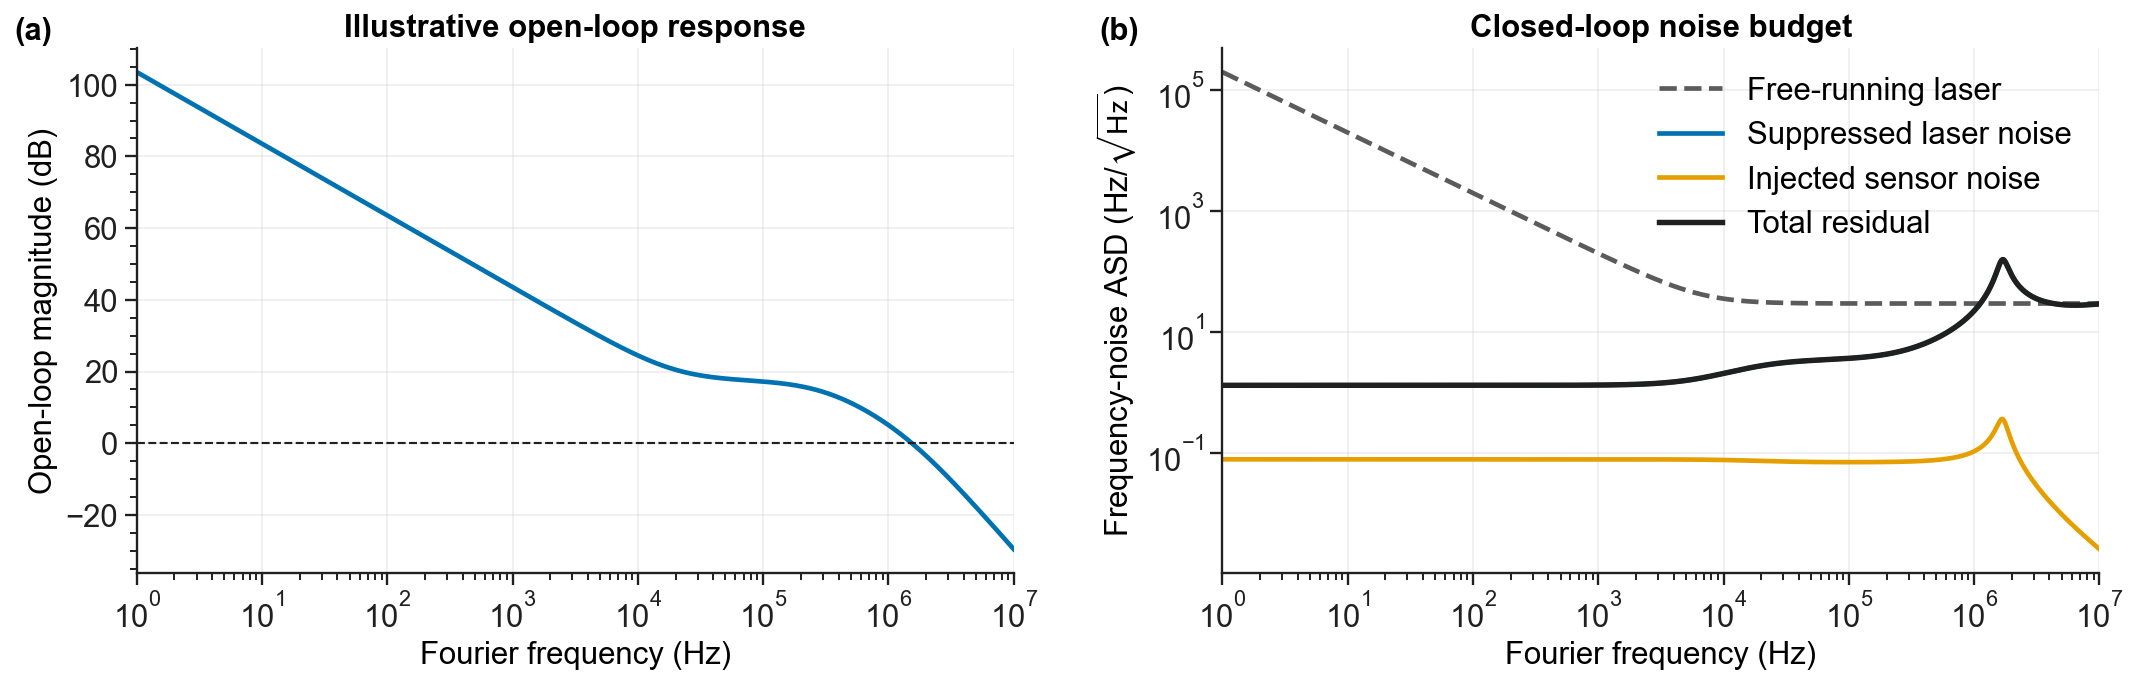

Approximate highest unity-gain crossing: 1531 kHz
This plot is a transfer-function lesson, not a fitted model of your hardware.


In [6]:
# Illustrative frequency-domain servo model (not a prescription for a particular laser).
f = np.logspace(0, 7, 2200)
s = 2j*pi*f
f_int = 1.5e5          # integrator strength
f_lead_z, f_lead_p = 2e4, 3e5
f_act = 1.5e6          # current actuator pole
delay = 70e-9          # aggregate loop delay
G = (2*pi*f_int/s) * (1+s/(2*pi*f_lead_z))/(1+s/(2*pi*f_lead_p))
G *= 1/(1+s/(2*pi*f_act)) * np.exp(-s*delay)
S = 1/(1+G)            # free laser noise -> residual
T = G/(1+G)            # sensor noise -> residual

# Toy amplitude spectral densities, Hz/sqrt(Hz).
asd_free = np.sqrt((2e5/f)**2 + 30**2)
asd_sensor = 0.08*np.ones_like(f)
asd_residual = np.sqrt((np.abs(S)*asd_free)**2 + (np.abs(T)*asd_sensor)**2)

fig, ax = plt.subplots(1, 2, figsize=(15.5, 5.4))
ax[0].semilogx(f, 20*np.log10(np.abs(G)), color=COLORS["blue"])
ax[0].axhline(0, color=COLORS["black"], lw=1.1, ls="--")
ax[0].set(
    xlabel="Fourier frequency (Hz)", ylabel="Open-loop magnitude (dB)",
    title="Illustrative open-loop response", xlim=(1, 1e7),
)

ax[1].loglog(f, asd_free, color=COLORS["gray"], ls="--", label="Free-running laser")
ax[1].loglog(f, np.abs(S)*asd_free, color=COLORS["blue"], label="Suppressed laser noise")
ax[1].loglog(f, np.abs(T)*asd_sensor, color=COLORS["orange"], label="Injected sensor noise")
ax[1].loglog(f, asd_residual, color=COLORS["black"], lw=2.8, label="Total residual")
ax[1].set(
    xlabel="Fourier frequency (Hz)",
    ylabel=r"Frequency-noise ASD (Hz/$\sqrt{\mathrm{Hz}}$)",
    title="Closed-loop noise budget", xlim=(1, 1e7),
)
ax[1].legend(loc="best")
polish_axes(ax)
fig.tight_layout(pad=1.6, w_pad=2.5)
plt.show()

crossings = np.where(np.diff(np.sign(20*np.log10(np.abs(G)))))[0]
if crossings.size:
    print(f"Approximate highest unity-gain crossing: {f[crossings[-1]]/1e3:.0f} kHz")
print("This plot is a transfer-function lesson, not a fitted model of your hardware.")

## 5. Practical diode-laser implementation

A sensible commissioning sequence is:

1. **Make the optical mode clean.** Use an isolator after the diode/ECDL; mode-match the EOM output to the cavity TEM$_{00}$; put the reflection detector behind a polarization-separating pickoff or circulator. Optical feedback can destabilize a diode dramatically.
2. **Identify scales.** Measure the cavity FSR, linewidth, visibility, modulation frequency/index, RF photodiode bandwidth, and actuator tuning coefficient. Check that sidebands do not overlap neighboring transverse or longitudinal modes.
3. **Set the RF quadrature.** Scan across a mode while adjusting mixer phase for a symmetric, steep odd error. Monitor transmission at the same time so the desired zero is unambiguous.
4. **Close only a slow loop first.** Verify the feedback sign at low gain. Then add the fast current/AOM branch and raise bandwidth while watching for ringing and actuator saturation.
5. **Calibrate.** Apply a known frequency dither to obtain $D$ in V/Hz; measure closed-loop transfer functions and actuator ranges; record an out-of-loop beat if available.
6. **Integrate with ion timing.** Keep the optical phase coherent across AOM pulses, stabilize the delivery fiber, and decide whether to hold, feed forward, or continue feedback during experimental dead time.

Directly modulating diode current can create the required sidebands, but current modulation generally produces both FM/PM and AM with a frequency-dependent phase. A dedicated EOM usually yields a cleaner and more stable PDH zero.

Useful oscilloscope diagnostics: cavity transmission, DC reflection, raw RF detector signal, mixer output before/after filtering, fast actuator command, and slow actuator command. A slow command drifting to a rail often means the temperature or cavity search logic—not the fast servo—is the real problem.

## 6. The AMO connection: what the ion experiences

In the rotating-wave approximation, a two-level carrier transition driven with resonant Rabi angular frequency $\Omega_R$ and angular detuning $\delta=2\pi(\nu_L-\nu_0)$ has excited-state probability

$$P_e(t,\delta)=\frac{\Omega_R^2}{\Omega_R^2+\delta^2}
\sin^2\!\left(\frac{t}{2}\sqrt{\Omega_R^2+\delta^2}\right).$$

A constant PDH offset shifts the spectroscopy line. Shot-to-shot low-frequency noise acts like a random detuning and lowers the average $\pi$-pulse fidelity. Faster phase/frequency noise drives dephasing according to its spectrum and the pulse-sequence filter function. Thus “laser linewidth” alone is not a complete qubit-noise specification; the frequency-noise PSD relative to the experimental timescale is more informative.

For a trapped ion, the laser also couples internal and motional degrees of freedom through $e^{i\mathbf{k}\cdot\hat{\mathbf{x}}}$. The Lamb–Dicke parameter for one mode is

$$\eta_{\rm LD}=|\mathbf{k}\cdot\hat{\mathbf{e}}_m|\sqrt{\frac{\hbar}{2m\omega_m}}. $$

PDH stabilization does not cool motion or remove magnetic-field shifts; it isolates one major term in the Hamiltonian—laser phase/frequency noise—so carrier and sideband dynamics can be controlled coherently.

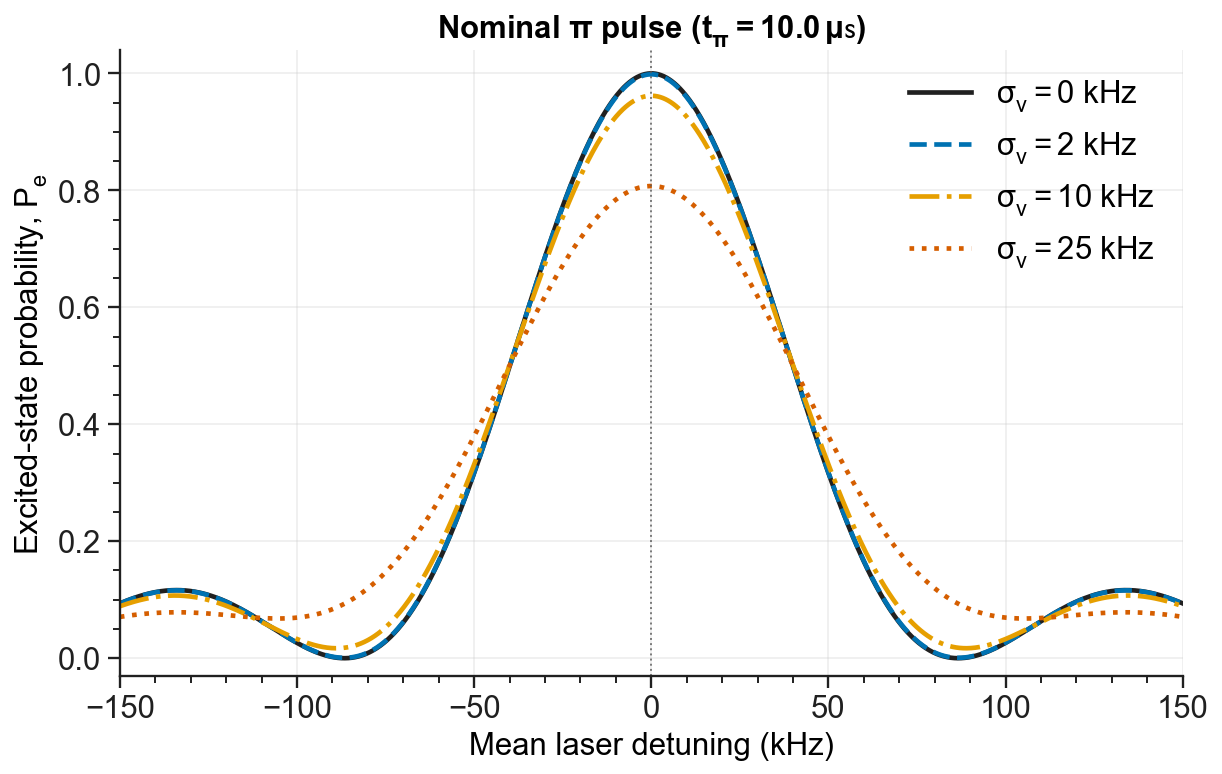

Ground-state extent x0 = 11.24 nm
Maximum Lamb-Dicke parameter at 729 nm = 0.097 (multiply by beam projection)
sigma_nu =   0.0 kHz -> mean resonant pi-pulse excitation 1.0000
sigma_nu =   2.0 kHz -> mean resonant pi-pulse excitation 0.9984
sigma_nu =  10.0 kHz -> mean resonant pi-pulse excitation 0.9618
sigma_nu =  25.0 kHz -> mean resonant pi-pulse excitation 0.8074


In [7]:
# Carrier pi pulse and quasi-static laser-frequency jitter.
f_rabi = 50e3                 # Omega_R/(2pi), Hz
Omega_R = 2*pi*f_rabi
t_pi = pi/Omega_R
detuning = np.linspace(-150e3, 150e3, 1201)
delta = 2*pi*detuning
Omega_eff = np.sqrt(Omega_R**2 + delta**2)
P = (Omega_R/Omega_eff)**2 * np.sin(Omega_eff*t_pi/2)**2

# Average over Gaussian detuning noise by deterministic quadrature.
sigma_values = [0, 2e3, 10e3, 25e3]
x = np.linspace(-5, 5, 801)
weights = np.exp(-x**2/2)
weights /= np.sum(weights)
averaged = {}
for sigma in sigma_values:
    if sigma == 0:
        averaged[sigma] = P
    else:
        shifted_delta = 2*pi*(detuning[:, None] - sigma*x[None, :])
        shifted_Omega = np.sqrt(Omega_R**2 + shifted_delta**2)
        shifted_P = (Omega_R/shifted_Omega)**2 * np.sin(shifted_Omega*t_pi/2)**2
        averaged[sigma] = shifted_P @ weights

fig, ax = plt.subplots(figsize=(9.2, 6.0))
curve_colors = [COLORS["black"], COLORS["blue"], COLORS["orange"], COLORS["red"]]
curve_styles = ["-", "--", "-.", ":"]
for (sigma, curve), color, linestyle in zip(averaged.items(), curve_colors, curve_styles):
    ax.plot(detuning/1e3, curve, color=color, ls=linestyle,
            label=fr"$\sigma_\nu={sigma/1e3:.0f}$ kHz")
ax.axvline(0, color=COLORS["gray"], lw=1.0, ls=":", alpha=0.8)
ax.set(
    xlabel="Mean laser detuning (kHz)",
    ylabel=r"Excited-state probability, $P_e$",
    title=fr"Nominal $\pi$ pulse ($t_\pi={t_pi*1e6:.1f}\,\mu\mathrm{{s}}$)",
    xlim=(-150, 150), ylim=(-0.03, 1.04),
)
ax.legend(loc="upper right")
polish_axes(ax, panel_labels=False)
fig.tight_layout(pad=1.5)
plt.show()

# Lamb-Dicke parameter for 40Ca+, 729 nm, 1 MHz mode, projection cos(theta)=1.
u = physical_constants["atomic mass constant"][0]
m_ca40 = 40*u
omega_m = 2*pi*1e6
x0 = np.sqrt(hbar/(2*m_ca40*omega_m))
eta_LD = (2*pi/wavelength)*x0
print(f"Ground-state extent x0 = {x0*1e9:.2f} nm")
print(f"Maximum Lamb-Dicke parameter at 729 nm = {eta_LD:.3f} (multiply by beam projection)")
for sigma in sigma_values:
    center = averaged[sigma][len(detuning)//2]
    print(f"sigma_nu = {sigma/1e3:5.1f} kHz -> mean resonant pi-pulse excitation {center:.4f}")

## 7. Numerical sensitivity and a compact noise budget

If the total detected DC power is $P_{\rm det}$ and detector responsivity is $\mathcal R$, the average photocurrent is $I=\mathcal RP_{\rm det}$. Its one-sided shot-noise amplitude spectral density is

$$i_{\rm shot}=\sqrt{2eI}\quad\mathrm{A}/\sqrt{\mathrm{Hz}}.$$

If a calibrated demodulated discriminator has slope $D_I=dI_{\rm err}/d\nu$, the equivalent frequency-noise floor is $S_{\nu,\rm shot}^{1/2}=i_{\rm shot}/|D_I|$. Mixer conversion loss, RF gain, impedance conventions, and the demodulation factor must be included consistently; therefore the code below treats $D_I$ as a measured system parameter rather than pretending the ideal optical normalization is the whole receiver.

Other important entries are cavity thermal noise, vibration sensitivity times acceleration noise, RAM-induced offsets, electronics noise divided by discriminator slope, residual free-running laser noise after $|1+G|^{-1}$ suppression, fiber phase noise after the cavity pickoff, and the atomic reference's quantum projection noise in the slow outer loop. Independent amplitude spectral densities add in quadrature.

In [8]:
P_detected = 200e-6       # W
responsivity = 0.55       # A/W near 729 nm; illustrative
D_I = 2.0e-8              # A/Hz, calibrated demodulated slope; illustrative
bandwidth_measure = 1e3   # Hz

I_dc = responsivity * P_detected
i_shot = np.sqrt(2*e*I_dc)
freq_asd_shot = i_shot/abs(D_I)
rms_in_band = freq_asd_shot*np.sqrt(bandwidth_measure)

print(f"DC photocurrent                    = {I_dc*1e6:.1f} microampere")
print(f"Shot-noise current ASD             = {i_shot*1e12:.3f} pA/sqrt(Hz)")
print(f"Equivalent frequency-noise ASD     = {freq_asd_shot:.4f} Hz/sqrt(Hz)")
print(f"White-noise RMS over {bandwidth_measure/1e3:.0f} kHz       = {rms_in_band:.3f} Hz")
print(f"Equivalent fractional ASD at 729 nm = {freq_asd_shot/(c/wavelength):.2e}/sqrt(Hz)")

# Offset example: a voltage offset divided by a measured voltage discriminator.
D_V = 0.8e-3             # V/kHz
V_offset = 2.0e-3        # V
lock_shift_hz = -V_offset/(D_V/1e3)
print(f"A {V_offset*1e3:.1f} mV offset at {D_V:.1e} V/kHz shifts the lock by {lock_shift_hz/1e3:.2f} kHz.")

DC photocurrent                    = 110.0 microampere
Shot-noise current ASD             = 5.937 pA/sqrt(Hz)
Equivalent frequency-noise ASD     = 0.0003 Hz/sqrt(Hz)
White-noise RMS over 1 kHz       = 0.009 Hz
Equivalent fractional ASD at 729 nm = 7.22e-19/sqrt(Hz)
A 2.0 mV offset at 8.0e-04 V/kHz shifts the lock by -2.50 kHz.


## 8. Troubleshooting by symptom

| Symptom | Likely physics | Useful check |
|---|---|---|
| No dispersive zero | no PM, wrong RF path, sidebands/cavity geometry wrong | view RF spectrum; scan cavity; verify $f_m$ and detector bandwidth |
| Error looks mostly absorptive/even | demodulation quadrature is wrong | adjust LO phase while scanning |
| Lock jumps to wrong feature | transverse mode or PDH sideband resonance | compare transmission; change scan span or $f_m$ |
| Zero moves with EOM power/temperature | RAM or etalon | block cavity to measure RAM; rotate polarization; temperature stabilize |
| High-frequency oscillation | inadequate phase margin, actuator resonance, delay | measure loop transfer; lower gain; add lead/notch/roll-off |
| Slow actuator rails | cavity drift, temperature setpoint, insufficient handoff | inspect integrator outputs; recenter temperature/PZT |
| In-loop error is quiet but ion is noisy | sensor-noise injection, fiber noise, AOM/RF phase noise, cavity motion | independent beat; fiber interferometer; Ramsey spectroscopy |
| Ion line drifts while lock remains firm | cavity is drifting relative to atom | atomic outer loop or comb reference |

The most informative habit is to attach every plotted voltage to a transfer function and calibration. “Quiet” in volts is not yet “stable” in Hz, and “stable at the cavity” is not yet phase coherent at the ion.

## 9. Takeaways and suggested numerical experiments

- A high-finesse cavity converts frequency detuning into a steep optical phase response.
- Phase modulation supplies coherent off-resonant sidebands; photodetection and synchronous demodulation compare them with the resonant carrier.
- The zero-crossing slope is the bridge from measured voltage noise to frequency noise. Offsets divided by this slope become real frequency errors.
- Feedback suppresses free laser noise only where loop gain is large and stable; it also transfers sensor and cavity noise to the laser.
- The ion sees the entire phase path after the cavity pickoff. AOM, RF reference, fiber, magnetic field, motion, and experimental timing remain part of the AMO problem.

Try these modifications:

1. Change $L$ and $\mathcal F$ and verify the linewidth and ringdown scaling.
2. Set $f_m$ comparable to the cavity linewidth and explain the loss of discriminator slope. Then ask what fails when $f_m$ approaches an FSR (the near-one-mode model used here no longer suffices).
3. Change $\eta$ away from critical coupling. Relate the remaining reflected carrier to impedance mismatch.
4. Add a constant error offset and verify $\delta\nu=-V_{\rm off}/D$.
5. Increase loop delay in the toy servo model and locate peaking near the unity-gain crossing.
6. Replace quasi-static Gaussian detuning in the ion model with a time-dependent phase-noise trace and compare Rabi and Ramsey sensitivity.

### Further reading

- R. W. P. Drever *et al.*, “Laser phase and frequency stabilization using an optical resonator,” *Applied Physics B* **31**, 97–105 (1983).
- E. D. Black, “An introduction to Pound–Drever–Hall laser frequency stabilization,” *American Journal of Physics* **69**, 79–87 (2001).
- D. A. Steck, *Quantum and Atom Optics*, sections on driven two-level systems and laser noise.

These references use slightly different sign, linewidth, Fourier-transform, and mixer-phase conventions. The observable content—odd zero crossing, calibrated slope, and closed-loop sensitivity—is convention independent.